<a href="https://colab.research.google.com/github/dath1s/NN-sem6/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BA%D0%B0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Описание ДЗ-1.

В первой домашке вы обучите свою первую нейронку.

За дз можно получить максимум 10 баллов. **Домашки довольно творческие, если замечу копию нотбука у другого студента то максимальный балл сниижается до 3 )**

Разбалловка:
*   **Воспроизводимость и читабельность кода - 6 баллов** (все воспроизвелось и все понятно для проверяющего - 6 баллов; есть непонятные моменты, но все воспроизвелось - 4 балла; непонятный код и/или воспроизводится с небольшой правкой - 2 балл; непонятный код и/или ничего не воспроизвелось - 0 баллов).
*   **Технический отчет - 4 балла** (приведены результаты сравнения и выводы что сделали чтоб перебить baseline\другую модель, к примеру одна модель лучше/хуже нейронки и тд - 4 балла, только результаты - 2 балл, ничего нет - 0 баллов).


Присылать домашки по ссылке https://forms.gle/W8jwbwA4EWagEbX66

# Первая нейросетка

Ну что ж, пришло время построить свою первую нейронную сеть. У нас будет искуственная задачка и мы посмотрим на её примере, как работают различные алгоритмы машинного обучения.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/НС/data.csv',index_col=0)

In [ ]:
df.head(10)

,x1,x2,y
0,-4.626272,-6.658988,0
1,-7.789640,0.262519,0
2,-8.739678,1.537758,0
3,-2.546441,-7.705224,0
4,-2.751506,-7.940187,0
5,0.303440,5.969639,0
6,-5.920224,1.339210,1
7,-7.555594,0.733846,1
8,5.995393,-4.607815,0
9,1.465613,4.338939,1


<Axes: >

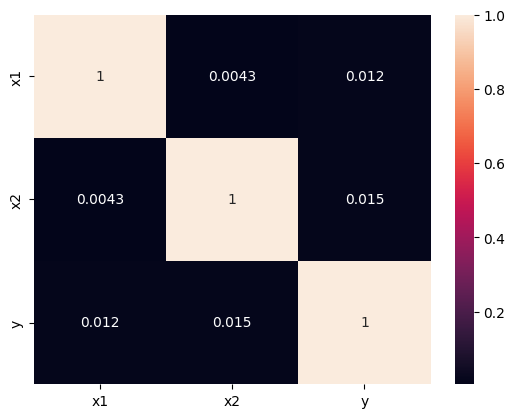

In [ ]:
sns.heatmap(df.corr(), annot=True)

Как и в любой задаче машинного обучения для начала надо визуализировать данные.
Не зря же нашу нейронную сеть мы так долго учим?


<Axes: xlabel='x1', ylabel='x2'>

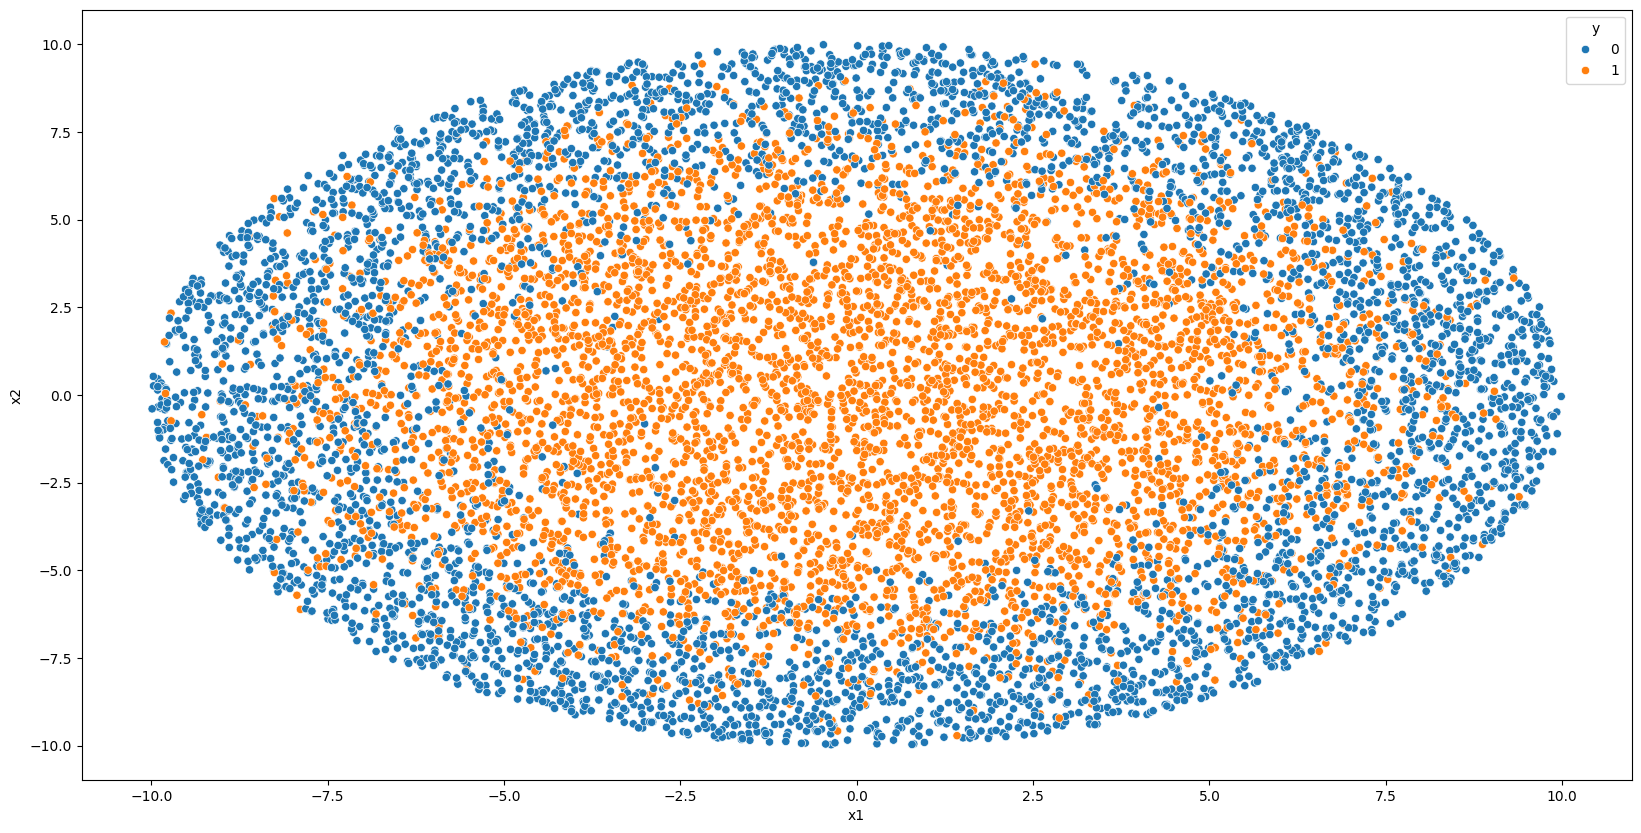

In [ ]:
plt.figure(figsize=(20, 10))
sns.scatterplot(x="x1", y="x2", hue="y", data = df)

После просмотра данных встает несколько вопросов:
 * 1) Можем ли мы построить идеальную модель ? Нет, т.к. нет четкого разделения классов. Н аграфике видны вкрыпления второго класса среди первого.
 * 2) Что ещё мы хотим знать о выборке? Соотношения между первым и вторым классом, коррелирование ответа с классом, наличие шумов в выборке
 * 3) Какие алгоритмы машинного обучения мы можем эффективно здесь использовать? Из наиболее простых это K-ближайших соседей, из посложнее случайный лес(нужно поиграть с глубиной леса) или простая нейронная сеть с малым количеством слоев(во избежание переобучения)

После описательного анализа приступим к построению моделей. Для начала посмотрим, что нам даст Логистическая регрессия.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# разобьем выборку на трэйн/тест
X_train, X_test, y_train, y_test = train_test_split(df[['x1','x2']], df['y'], test_size = 0.33)

Точность нашей модели 0.5981818181818181


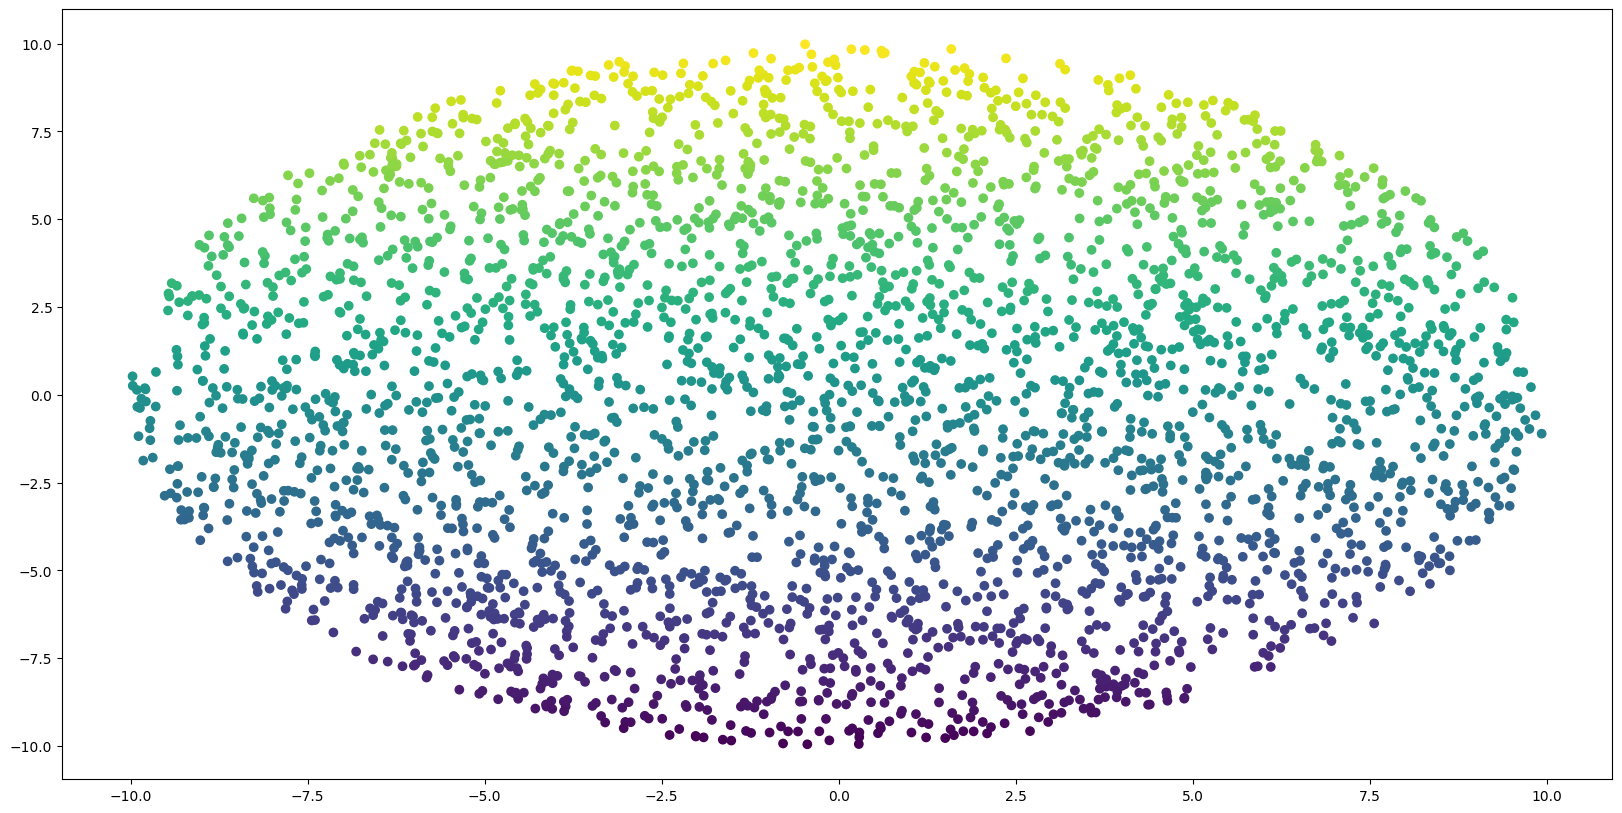

In [ ]:
from sklearn.linear_model import LogisticRegression


#########################################
# Ваш код для Логистической регрессии
logreg = LogisticRegression()
logreg.fit(X_train, y_train)


predict_logit =  logreg.predict(X_test)
predict_log_proba = logreg.predict_proba(X_test)[:, 1]

#########################################


print(f'Точность нашей модели {accuracy_score(predict_logit, y_test)}')

# Заодно завизуализируем полученные результаты
plt.figure(figsize=(20, 10))
plt.scatter(X_test['x1'], X_test['x2'], c = predict_log_proba)
plt.show()

Вообще машинное обучение не только про алгоритмы (нейронные сети не исключение),
 а скорее про обработку данных. Что нам надо добавить, чтобы наш алгоритм отработал без проблем? Новых фичей(комбинация или преобразования полей)

Точность нашей модели 0.8369696969696969


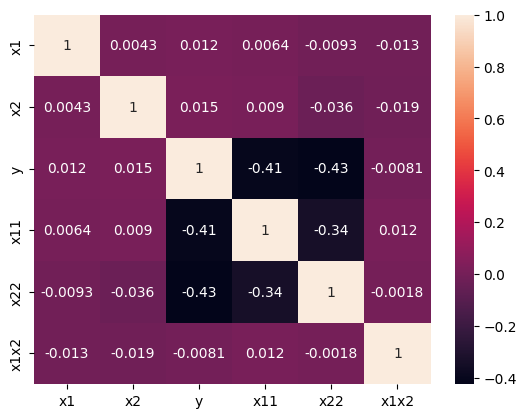

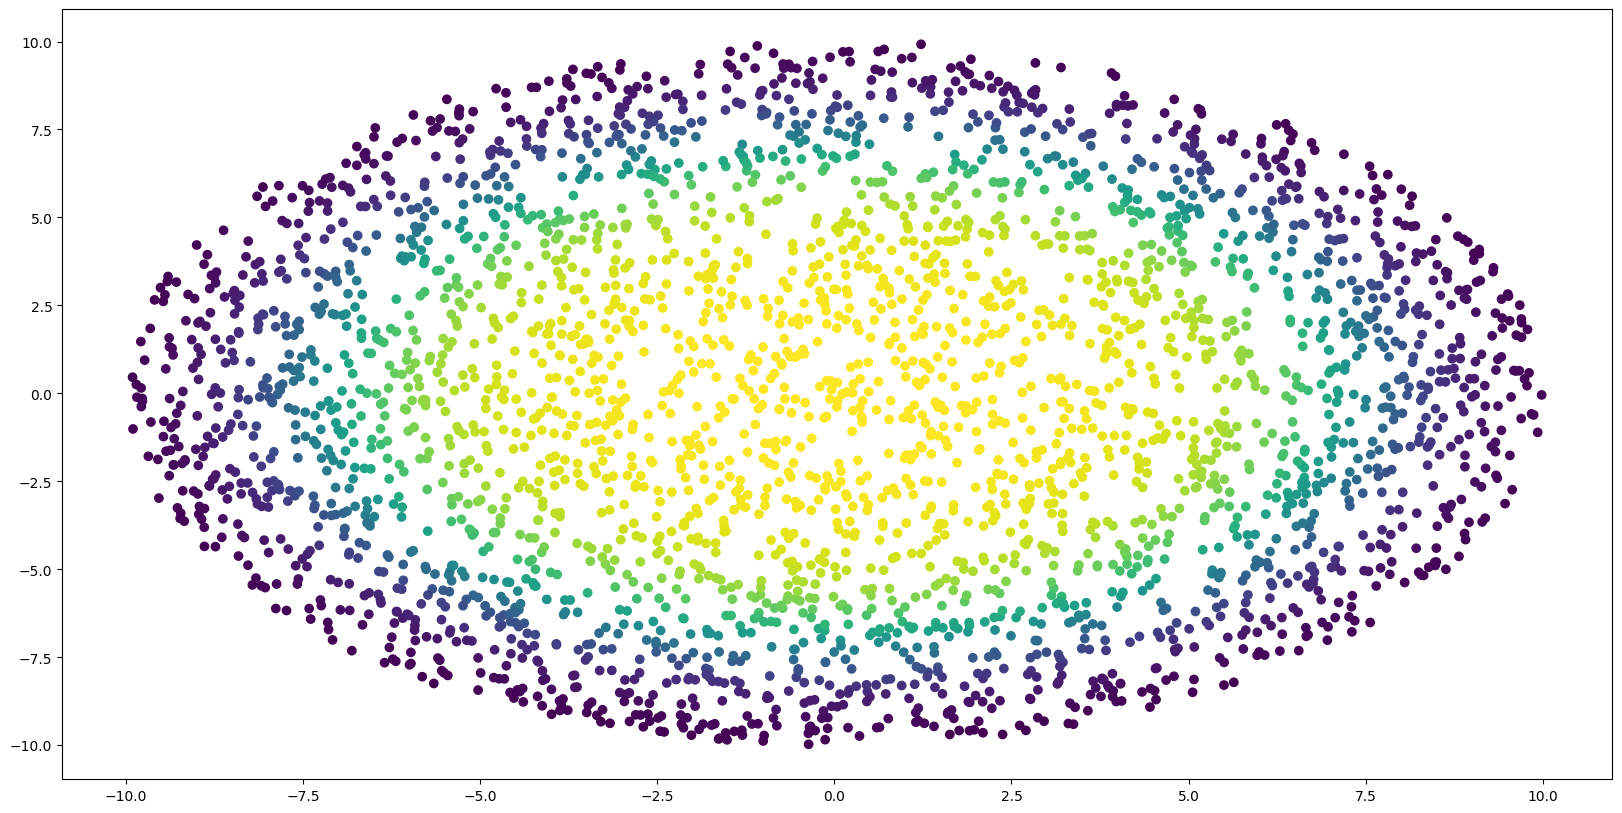

In [ ]:
# Повторяем наш код, только с новыми фичами - смотрим на магию
df_new = df.copy()

#########################################
# ваш код для фичей и новой модели

df_new['x11'] = df_new['x1'] ** 2
df_new['x22'] = df_new['x2'] ** 2
df_new['x1x2'] = df_new['x1'] * df_new['x2']

sns.heatmap(df_new.corr(), annot=True)

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(df_new[['x1', 'x2', 'x11', 'x22', 'x1x2']],
                                                                    df_new['y'], test_size = 0.33)

logreg2 = LogisticRegression()
logreg2.fit(X_train_new, y_train_new)


predict_logit =  logreg2.predict(X_test_new)
predict_log_proba = logreg2.predict_proba(X_test_new)[:, 1]

#########################################

print(f'Точность нашей модели {accuracy_score(predict_logit,y_test_new)}')

plt.figure(figsize=(20, 10))
plt.scatter(X_test_new['x1'], X_test_new['x2'], c = predict_log_proba)
plt.show()

Переходим к следующиму классу алгоритмов - деревья решений. Какая особенность есть у деревьев? Какой параметр надо зафикисировать, чтобы эта особенность не испортила обучение? легко переобучаются, для тогоm, чтоб этого не случилось фиксируе max_depth - максимальная глубина дерева

Точность нашей модели 0.7718181818181818


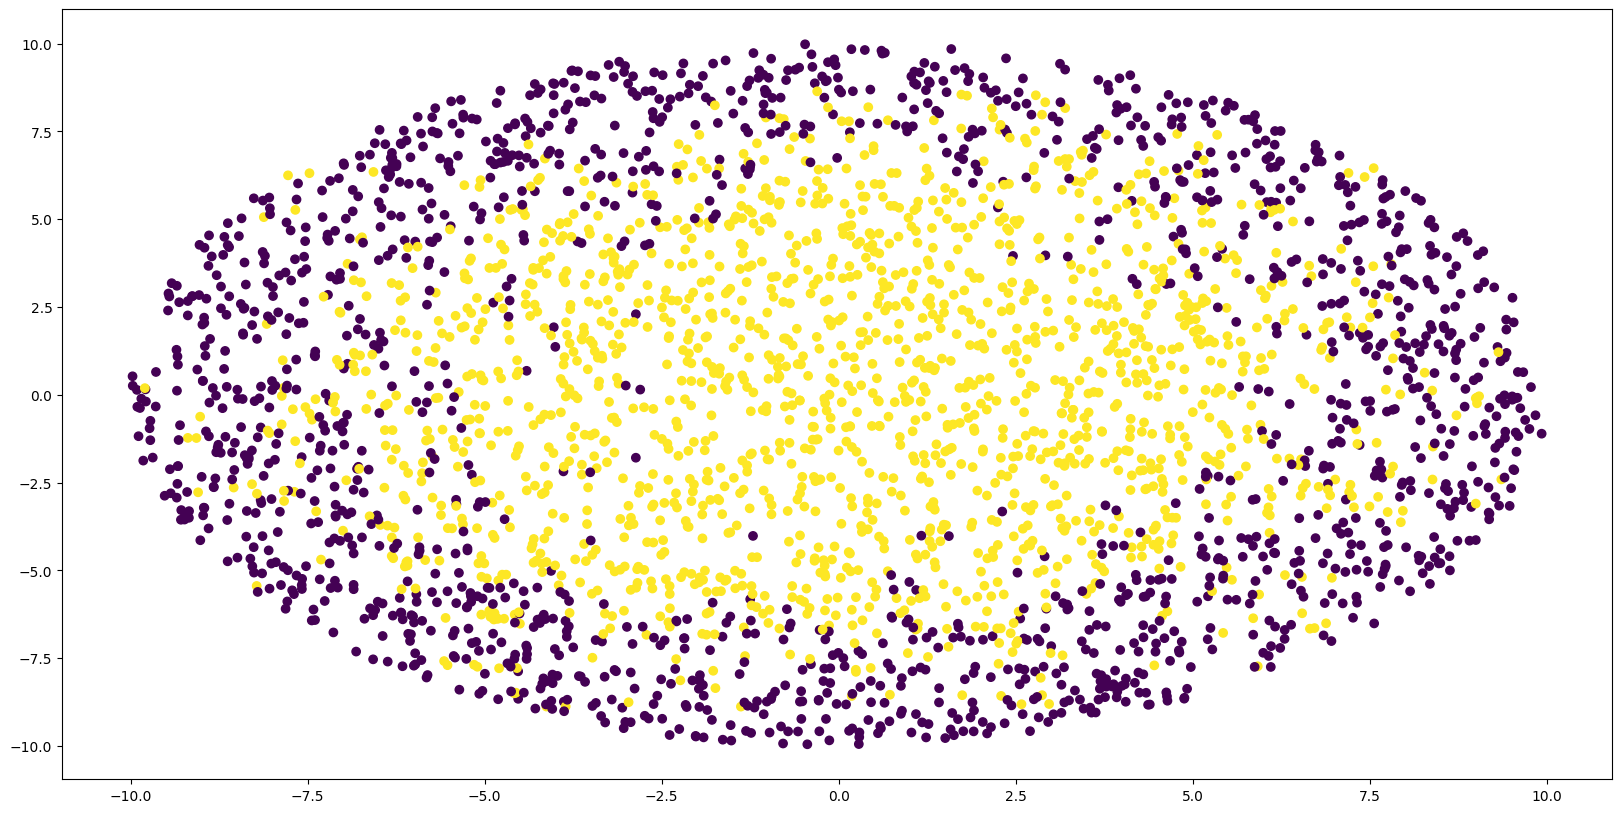

In [ ]:
from sklearn.tree import DecisionTreeClassifier

#########################################
dectreeclass = DecisionTreeClassifier(max_depth=43, random_state=True)
dectreeclass.fit(X_train, y_train)

predict_tree = dectreeclass.predict(X_test)
print(f'Точность нашей модели {accuracy_score(predict_tree, y_test)}')

predict_tree_proba = dectreeclass.predict_proba(X_test)[:, 1]

#########################################

plt.figure(figsize=(20,10))
plt.scatter(X_test['x1'], X_test['x2'], c = predict_tree_proba)
plt.show()

Поможет ли в данном случае ансамблирование? Когда в целом ансамбль дает хорошие результаты? Да, поможет. Очень хорошо ансамблирование работает, когда нет четкого разделения между классами.

Точность нашей модели 0.8121212121212121


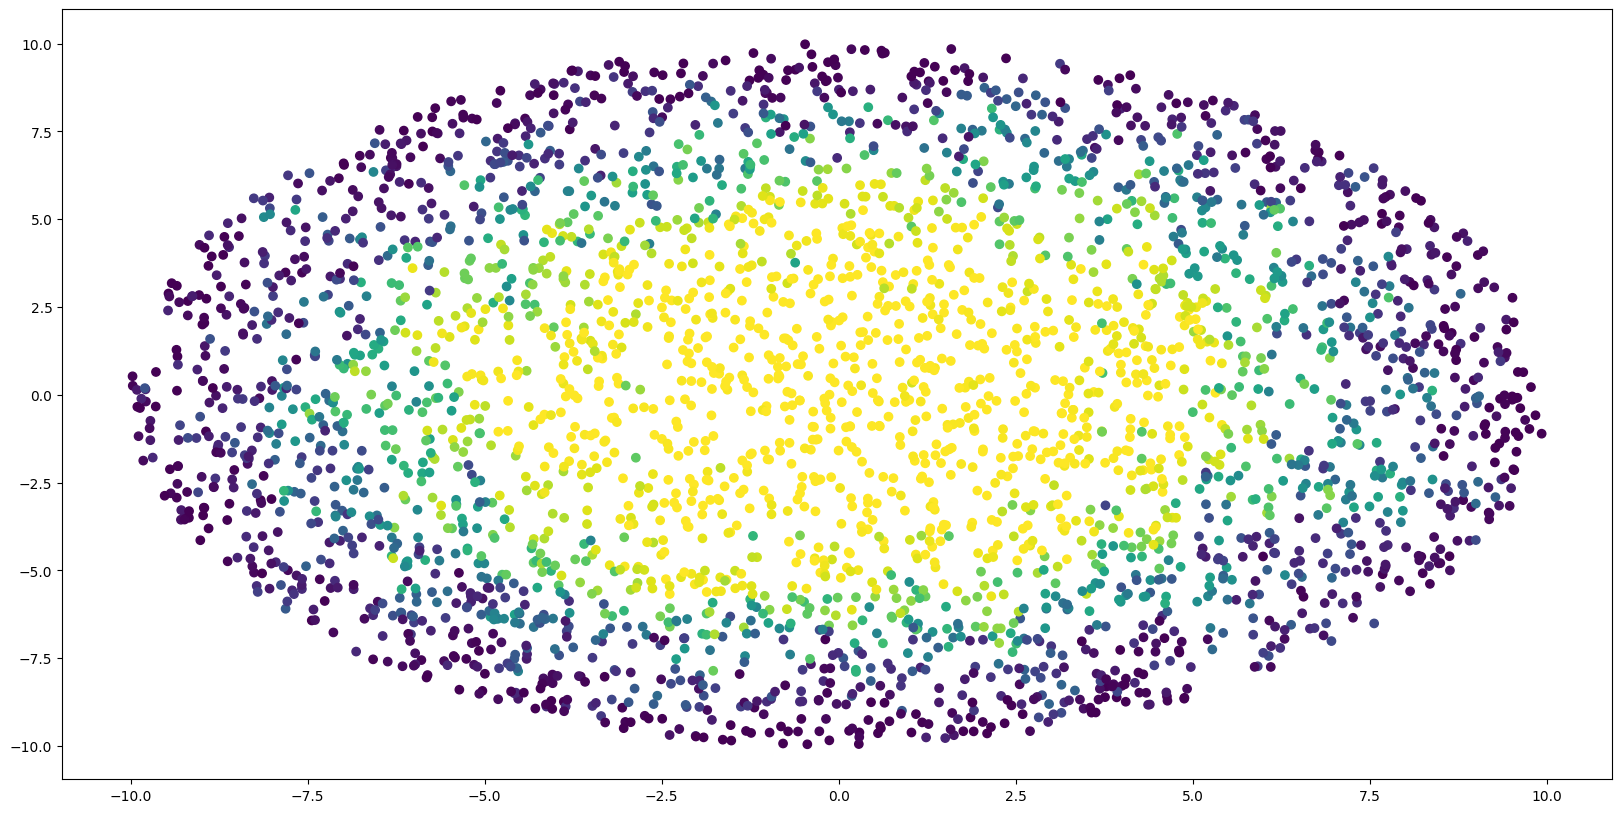

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#########################################
# Ваш код
randforclass = RandomForestClassifier(max_depth=43, random_state=True)
randforclass.fit(X_train, y_train)


predict_forest = randforclass.predict(X_test)
print(f'Точность нашей модели {accuracy_score(predict_forest, y_test)}')

predict_forest_proba = randforclass.predict_proba(X_test)[:, 1]

#########################################

plt.figure(figsize=(20, 10))
plt.scatter(X_test['x1'], X_test['x2'], c = predict_forest_proba)
plt.show()

ну и наконец мы добрались до нейронок - пора собрать нашу нейроночку под эту задачу.

Соберем простенькую нейронку - (пример архитектуры - 2 слоя по 5 нейронов в каждом). Смотрим на тетрадку(семинар) и копипастим все нужное сюда!

In [ ]:
!pip install torchmetrics

import torch.nn as nn # содержит функции для реалзации архитектуры нейронных сетей
import torch.nn.functional as F # содержит различные функции активации и не только
import torch.optim as optim
import torch.utils.data as data_utils
import torch

from torchmetrics import Accuracy

In [ ]:
INPUT_SIZE = 2
HIDDEN_SIZE = 5
OUTPUT_SIZE = 2
EPOCHS = 100
BATCH_SIZE = 128

In [34]:
def create_data_loader(X_train, y_train, X_test, y_test):
    train_tensor = data_utils.TensorDataset(
        torch.tensor(X_train.astype(np.float32)),
        torch.tensor(y_train)
    )
    train_loader = data_utils.DataLoader(
        dataset=train_tensor,
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    test_tensor = data_utils.TensorDataset(
        torch.tensor(X_test.astype(np.float32)),
        torch.tensor(y_test)
    )
    test_loader = data_utils.DataLoader(
        dataset=test_tensor,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    return train_loader, test_loader

In [35]:
train_loader, test_loader = create_data_loader(X_train.values, y_train.values, X_test.values, y_test.values)

In [51]:
def build_simple_model():
    model = nn.Sequential(
        nn.Linear(in_features=INPUT_SIZE, out_features=HIDDEN_SIZE),
        nn.ReLU(),
        nn.Linear(in_features=HIDDEN_SIZE, out_features=HIDDEN_SIZE),
        nn.ReLU(),
        nn.Linear(in_features=HIDDEN_SIZE, out_features=OUTPUT_SIZE),
        nn.Sigmoid(),
    )

    return model

In [52]:
model = build_simple_model()

In [53]:
model

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=2, bias=True)
  (5): Sigmoid()
)

In [54]:
LEARNING_RATE = 1e-3

# Оптимизатор
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Функция потерь
criterion = nn.CrossEntropyLoss()

# Метрика
accuracy = Accuracy(task="binary")

In [55]:
train_loss_values = []
train_accuracy_values = []
valid_loss_values = []
valid_accuracy = []

def run_train():
    step = 0

    for epoch in range(EPOCHS + 1):
        running_loss = []
        running_acc = []
        model.train()
        for features, label in train_loader:
            optimizer.zero_grad()

            output = model(features)
            loss = criterion(output, label)
            loss.backward()

            softmax = torch.nn.Softmax(dim=1)
            pred_probs = softmax(output)[:, 1]

            acc = accuracy(pred_probs, label).item()

            optimizer.step()

            running_loss.append(loss.item())
            running_acc.append(acc)

            step += 1

        train_loss_values.append(np.mean(running_loss))
        train_accuracy_values.append(np.mean(running_acc))
        if epoch % 20 == 0:
            print('EPOCH %d : train_loss: %f train_acc: %f' % (epoch, train_loss_values[-1], train_accuracy_values[-1]))

        running_loss = []
        running_acc = []
        model.eval()
        for features, label in test_loader:
            output = model(features)
            loss = criterion(output, label)

            pred_probs = softmax(output)[:, 1]

            acc = accuracy(pred_probs, label).item()

            running_loss.append(loss.item())
            running_acc.append(acc)

        valid_loss_values.append(np.mean(running_loss))
        valid_accuracy.append(np.mean(running_acc))
        if epoch % 20 == 0:
            print('EPOCH %d : valid_loss: %f valid_acc: %f' % (epoch, valid_loss_values[-1], valid_accuracy[-1]))

    return train_loss_values, train_accuracy_values, valid_loss_values, valid_accuracy

In [56]:
train_loss_values, train_accuracy_values, valid_loss_values, valid_accuracy_values = run_train()

EPOCH 0 : train_loss: 0.708056 train_acc: 0.511873
EPOCH 0 : valid_loss: 0.700941 valid_acc: 0.507981
EPOCH 20 : train_loss: 0.503028 train_acc: 0.824775
EPOCH 20 : valid_loss: 0.493540 valid_acc: 0.836995
EPOCH 40 : train_loss: 0.479045 train_acc: 0.831730
EPOCH 40 : valid_loss: 0.469116 valid_acc: 0.843005
EPOCH 60 : train_loss: 0.474792 train_acc: 0.834142
EPOCH 60 : valid_loss: 0.464052 valid_acc: 0.842019
EPOCH 80 : train_loss: 0.471662 train_acc: 0.836581
EPOCH 80 : valid_loss: 0.463033 valid_acc: 0.842536
EPOCH 100 : train_loss: 0.472181 train_acc: 0.835924
EPOCH 100 : valid_loss: 0.462457 valid_acc: 0.843137


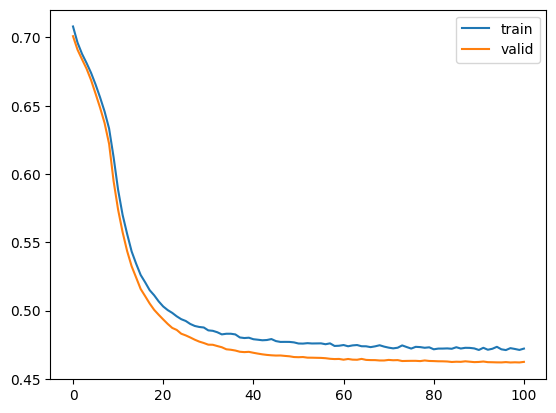

In [59]:
plt.plot(train_loss_values, label='train')
plt.plot(valid_loss_values, label='valid')
plt.legend()

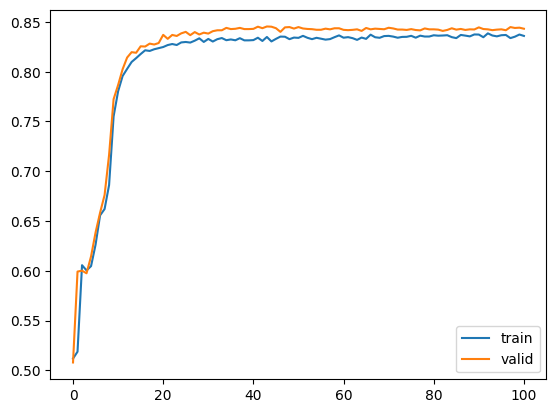

In [58]:
plt.plot(train_accuracy_values, label='train')
plt.plot(valid_accuracy_values, label='valid')
plt.legend()

Точность нашей модели 0.8433333333333334


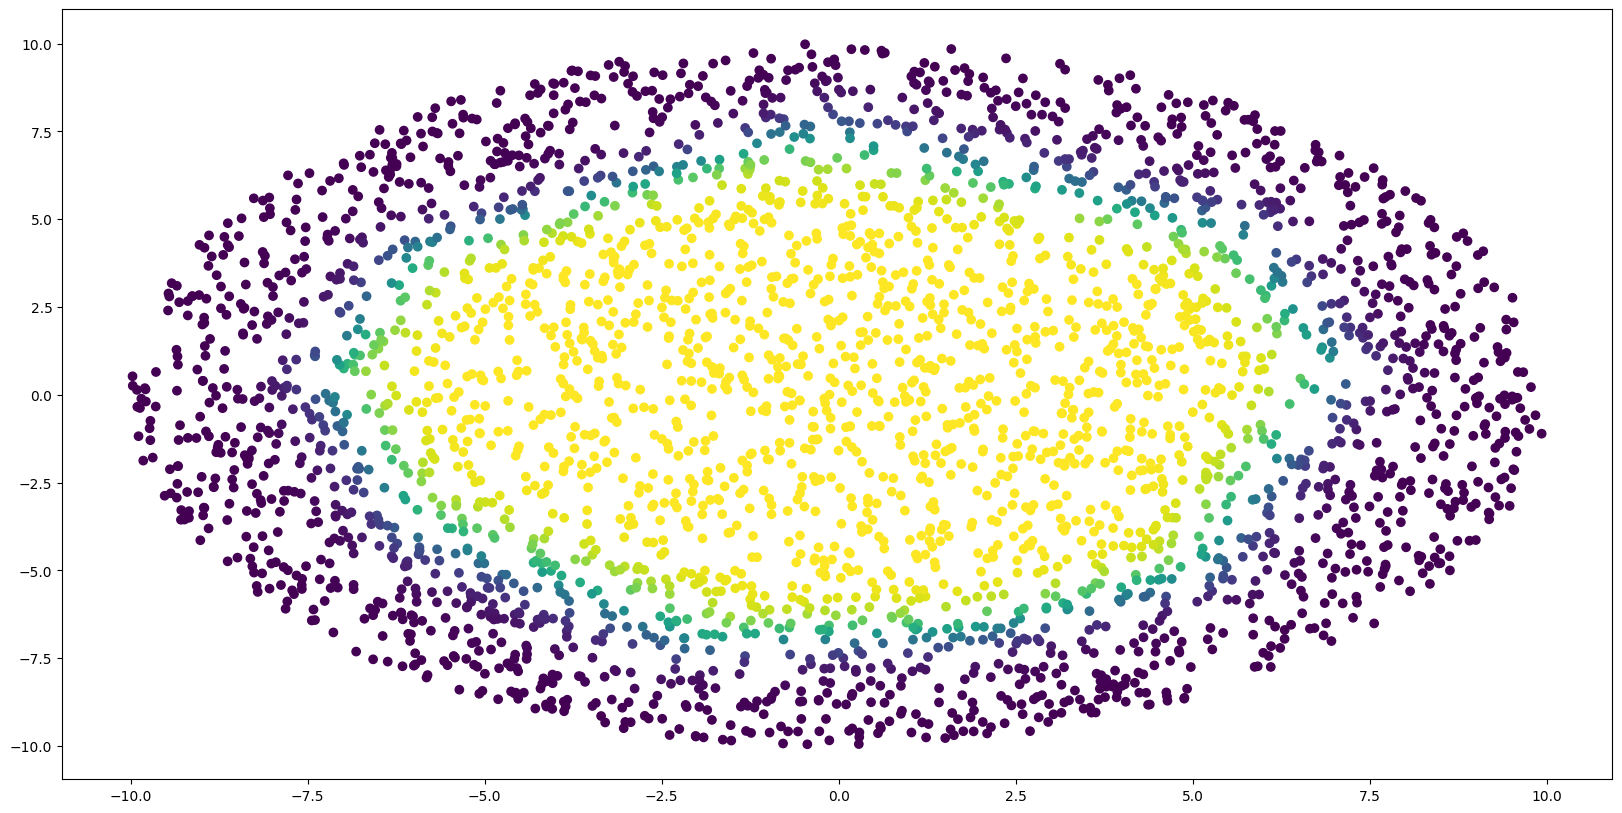

In [62]:
#########################################
# Ваш код

predict_neural = model.forward(torch.tensor(X_test.values.astype(np.float32)))
predict_classes = torch.argmax(predict_neural, dim=1)

print(f"Точность нашей модели {accuracy_score(predict_classes, y_test)}")
#########################################

plt.figure(figsize=(20, 10))
plt.scatter(X_test["x1"], X_test["x2"], c=predict_neural[:, 1].detach())
plt.show()